# MITGCM Regional Temporal Scale Analysis 

**Purpose**: Code for preforming the regional time scale analysis. Here, we compute the decorrelation time scale for a subset of the model domain at each grid point. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize, segment_time_series
from lsf import unweighted_lsf, detrend

Set data analysis parameters

In [4]:
# Set processing parameters
option_plot          = 0            # Specifies if supplementary plots are plotted
option_var           = 'ssh'    # Specifies which variable will analyzed. Options include: temp, sal, density, uvel, vvel, ssh
option_depth         = 0.5          # Specifies the depth level in meter at which the decorrelation data is computed
option_unc           = 1

# Set time and space parameters
T            = 1*(60)*(60)                   # Spcifies the time interval for model run. Units: seconds  
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs_server/mitgcm/scale_analysis/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 16

plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load mitgcm data netcdf files 

In [6]:
#--- MITgcm Data ---# 
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density'):
    filename = PATH + "mitgcm_intermediate_data_TSD_hrly_map_depth_" + str(option_depth) + "m.nc"
elif (option_var == 'uvel') | (option_var == 'vvel'):
    filename = PATH + "mitgcm_intermediate_data_vel_hrly_map_depth_" + str(option_depth) + "m.nc"
elif option_var == 'ssh':
    filename = PATH + "mitgcm_intermediate_data_ssh_hrly_map_surface.nc"
nc = Dataset(filename, 'r')

# Extract data variables
if (option_var == 'temp') | (option_var == 'sal') | (option_var == 'density') | (option_var == 'uvel') | (option_var == 'vvel'):
    depth = nc.variables['Depth'][:]
lon = nc.variables['lon'][:]
lat = nc.variables['lat'][:]
time =  num2date(nc.variables['time'][:], nc.variables['time'].units)

if option_var == 'temp':
    data = nc.variables['CTemp'][:]
elif option_var == 'sal':
    data = nc.variables['ASal'][:]
elif option_var == 'density':
    data = nc.variables['SIG'][:]
elif option_var == 'uvel':
    data = nc.variables['u'][:]
elif option_var == 'vvel':
    data = nc.variables['v'][:]
elif option_var == 'ssh':
    data = nc.variables['ssh'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

Read in bathymetry data

In [7]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Plot the spatial domain

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


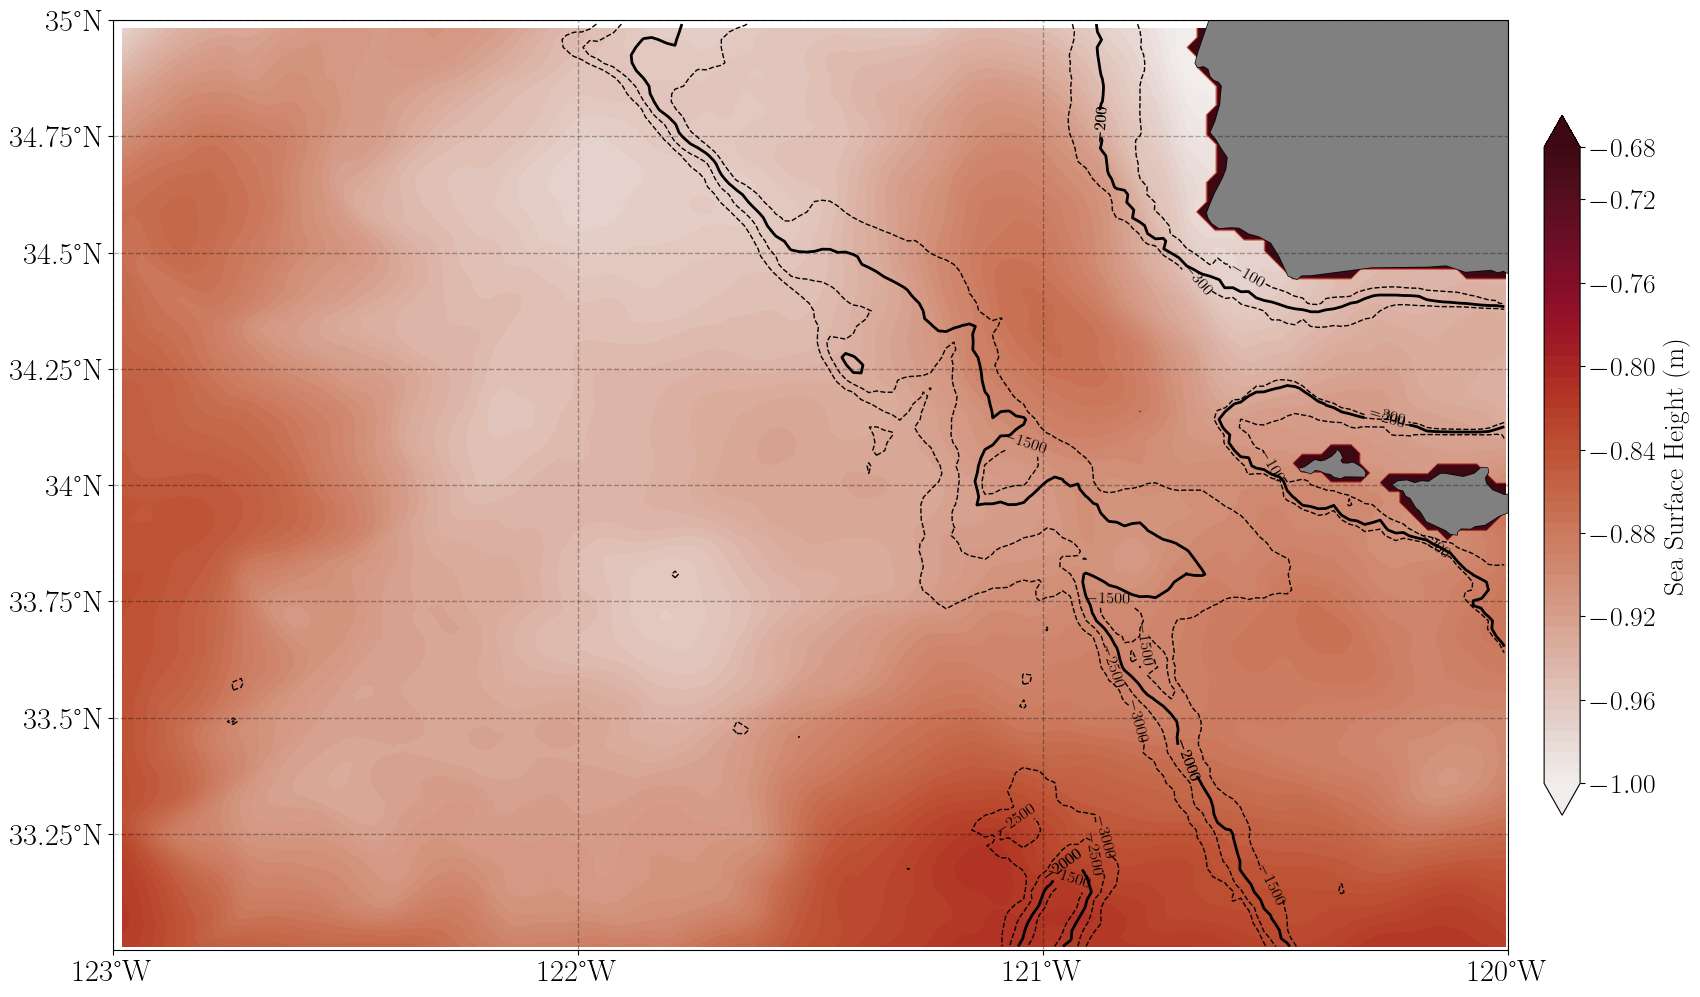

In [12]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35

# Specify data specific attributes 
if option_var == 'temp':
    cmap = cmocean.cm.thermal
    label = r'Conservative Temperature ($^\circ$C)'
    levels = np.arange(13,15.25+0.1,0.1) 
elif option_var == 'sal':
    cmap = cmocean.cm.haline
    label = r'Absolute Salinity (g/kg)'
    levels = np.arange(32.85,33.75 + 0.02,0.02)
elif option_var == 'density': 
    cmap = cmocean.cm.dense
    label = r'Potential Density (kg/m$^{3}$)'
    levels = np.arange(24.5,25.2 + 0.025,0.025)
elif option_var == 'ssh': 
    cmap = cmocean.cm.amp
    label = r'Sea Surface Height (m)'
    levels = np.arange(-1,-0.7 + 0.005,0.005)

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot potential temperature
mesh = axes.contourf(
    lon, lat, data[100,:,:], levels=levels, # 100, 400
    transform=ccrs.PlateCarree(),
    cmap=cmap,  
    shading="auto", 
    extend='both'
)

# Plot depth contour lines
level_innershelf = np.arange(-300,0,100)
levels_midshelf = np.arange(-3000,-1000,500)
contour1 = axes.contour(lon_grid, lat_grid, bathy_grid,levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, bathy_grid,levels=[-2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, bathy_grid,levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, bathy_grid,levels=[-200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="neither",
    cbar_label=label,
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

Preform scale analysis

In [13]:
if option_unc == True: 
    
    # Set parameters
    w1, w2        = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
    segment_years = 1 
    overlap       = 0.5

    # Obtain a example segment 
    segments = segment_time_series(time_dt, data[:,0,0], segment_years=segment_years, overlap=overlap)

    # Set dimensions     
    nseg,ntime  = np.shape(segments)[0], np.shape(segments)[2]
    _,nlat,nlon = np.shape(data)

    # Set autocorrelation parameters
    lag       = ntime
    norm      = 0
    estimator = 'biased'

    # Convert to seconds since start time
    t0 = time_dt[0]
    time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

    # Initialize arrays 
    Lt             = np.zeros((nlat,nlon))
    Lt_stdm        = np.zeros((nlat,nlon))
    cn_lon = 0 

    # Loop through longitude 
    for ilon in range(0,nlon):
        
        # Set progress bar
        progress = (ilon + 1) / (len(lon)-1)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Set latitude counter 
        cn_lat = 0

        # Loop through latitude
        for ilat in range(0,nlat):
            
            # Initialize the ith time series 
            data_ts = data[:,ilat,ilon]

            # Try statement to handle masked values associated with land
            try:

                # Remove annual and semi-annual cycle 
                hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
                data_ts_rm = data_ts - hfit

                # Segment the time series 
                segments = segment_time_series(time_dt, data_ts_rm, segment_years=segment_years, overlap=overlap)

                # Initialize arrays
                autocorr_seg   = np.zeros((nseg,ntime))
                time_scale_seg = np.zeros((nseg,ntime))

                # Loop through segments
                for i, (tseg, dseg) in enumerate(segments):

                    # Compute the elapsed time from beginning of segmented time series (units: seconds)
                    t0 = tseg[0]
                    time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
                    
                    # Detrend data record 
                    data_dt = detrend(dseg, time_elapsed_seg, mean = 0)

                    # Compute autocorrelation function
                    lag = len(time_elapsed_seg)
                    autocorr_seg[i,:], _, _, _, time_scale_seg[i,:], _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, lag, estimator, norm)

                # Compute the mean autocorrelation function 
                meanAutocorr = np.nanmean(autocorr_seg, axis=0)

                # Compute the standard deviation and the number of samples 
                stdAutocorr = np.nanstd(autocorr_seg, axis=0, ddof=1)
                nAutocorr   = np.count_nonzero(~np.isnan(autocorr_seg), axis=0)

                # Compute the standard error of the mean (assuming that each data point is an independent observations)
                stdmAutocorr   = stdAutocorr/np.sqrt(nAutocorr)

                # Compute the decorrelation scale 
                Lt[ilat,ilon]  = compute_decor_scale_optimize(meanAutocorr,time_scale_seg[0,:],T,'unbiased',norm)

                # Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
                Lt_ustd = compute_decor_scale_optimize(meanAutocorr + stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',norm)
                Lt_lstd = compute_decor_scale_optimize(meanAutocorr - stdmAutocorr ,time_scale_seg[0,:] ,T,'unbiased',norm)

                # Compute the average standard error 
                std_upper = Lt_ustd - Lt[ilat,ilon]
                std_lower = abs(Lt_lstd - Lt[ilat,ilon])
                Lt_stdm[ilat,ilon]  = np.mean([std_upper, std_lower])

            except Exception: 

                # Print warining message 
                print('Masked time series! Skipping grid point')

            # Set latitude counter
            cn_lat = cn_lat + 1

        # Set longitude counter
        cn_lon = cn_lon + 1

    # Convert time scale to units of days
    Lt_days      = Lt*(1/60)*(1/60)*(1/24)
    Lt_stdm_days = Lt_stdm*(1/60)*(1/60)*(1/24)

else:

    # Set parameters
    ntime,nlat,nlon = np.shape(data)
    lag = ntime
    w1, w2 = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec
    estimator = 'biased'

    # Convert to seconds since start time
    t0 = time_dt[0]
    time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

    # Initialize arrays 
    Lt             = np.zeros((nlat,nlon))
    cn_lon = 0 

    # Loop through longitude 
    for ilon in range(0,nlon):
        
        # Set progress bar
        progress = (ilon + 1) / (len(lon)-1)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Set latitude counter 
        cn_lat = 0

        # Loop through latitude
        for ilat in range(0,nlat):
            
            # Initialize the ith time series 
            data_ts = data[:,ilat,ilon]

            # Try statement to handle masked values associated with land
            try:

                # Remove annual and semi-annual cycle 
                hfit, x_data, x_data_sigma, _ = unweighted_lsf(data_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
                data_ts_rm = data_ts - hfit

                # Detrend data record 
                data_dt = detrend(data_ts_rm, time_elapsed, mean = 0)

                # Compute autocorrelation function
                autocorr, _, _, _, time_scale, _ = compute_autocorr_optimize(data_dt, time_elapsed, lag, estimator, 0)

                # Compute the decorrelation scale
                Lt[cn_lat,cn_lon] = compute_decor_scale_optimize(autocorr,time_scale,T,'unbiased',0)

            except Exception: 

                # Print warining message 
                print('Masked time series! Skipping grid point')

            # Set latitude counter
            cn_lat = cn_lat + 1

        # Set longitude counter
        cn_lon = cn_lon + 1

    # Convert time scale to units of days
    Lt_days = Lt*(1/60)*(1/60)*(1/24)

Progress: 86.7%

/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/autocorr.py:157: RuntimeWarning: invalid value encountered in scalar divide
  rho[k] = R[k] / Rnorm
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_30131/2536506555.py:75: RuntimeWarning: Mean of empty slice
  meanAutocorr = np.nanmean(autocorr_seg, axis=0)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Masked time series! Skipping grid point
Progress: 92.3%Masked time series! Skipping grid point
Masked time series! Skipping grid point
Progress: 93.0%Masked time series! Skipping grid point
Masked time series! Skipping grid point
Progress: 94.4%Masked time series! Skipping grid point
Progress: 95.1%Masked time series! Skipping grid point
Progress: 97.2%Masked time series! Skipping grid point
Progress: 100.7%Masked time series! Skipping grid point


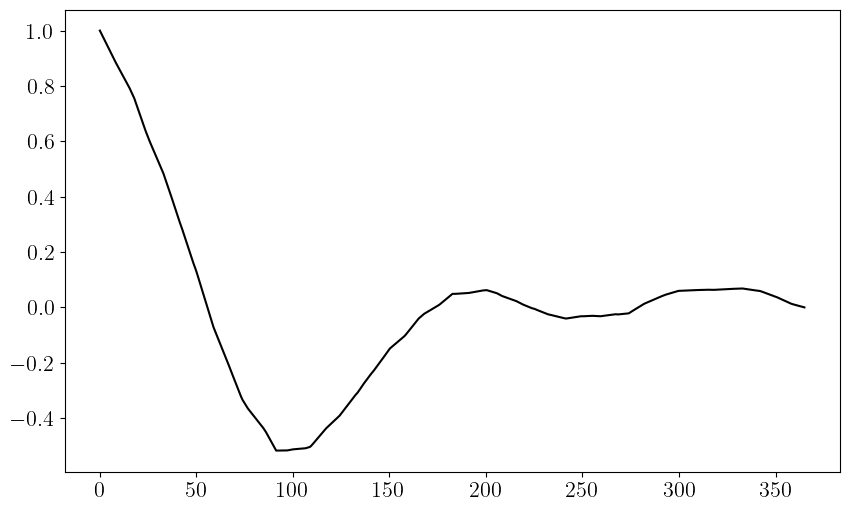

In [34]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(time_scale_seg[0,:]/(86400),meanAutocorr, '-k') 

Plot the spatial map of the temporal decorrelation scale 

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


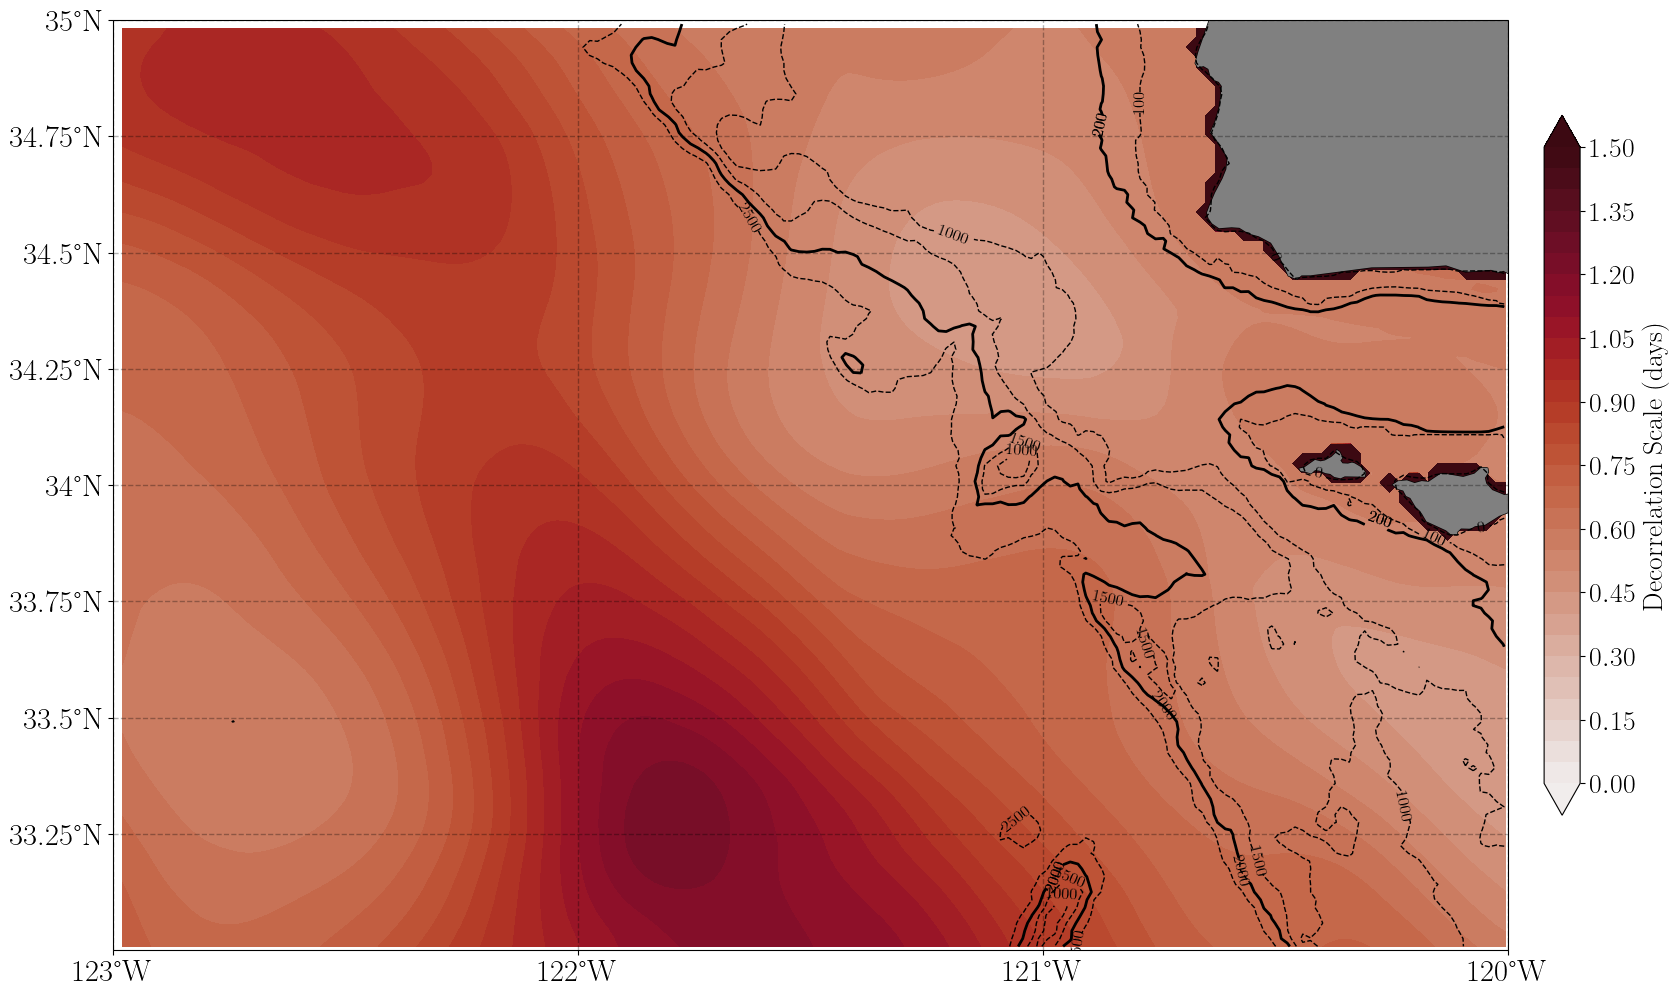

In [26]:
# Set plotting parameters 
levels = np.arange(0,1.5 + 0.05,0.05) 

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
mesh = axes.contourf(
    lon, lat, Lt_days, levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.amp,  
    shading="auto", 
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label=r'Decorrelation Scale (days)',
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

(np.float64(16801.0), np.float64(16804.0))

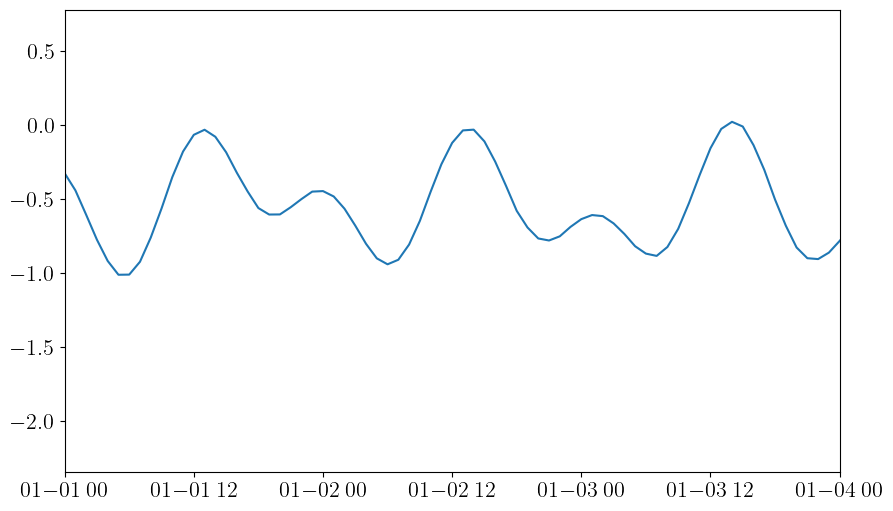

In [29]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(time_dt, data[:,80,80])
ax.set_xlim(datetime(2016,1,1), datetime(2016,1,4))

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


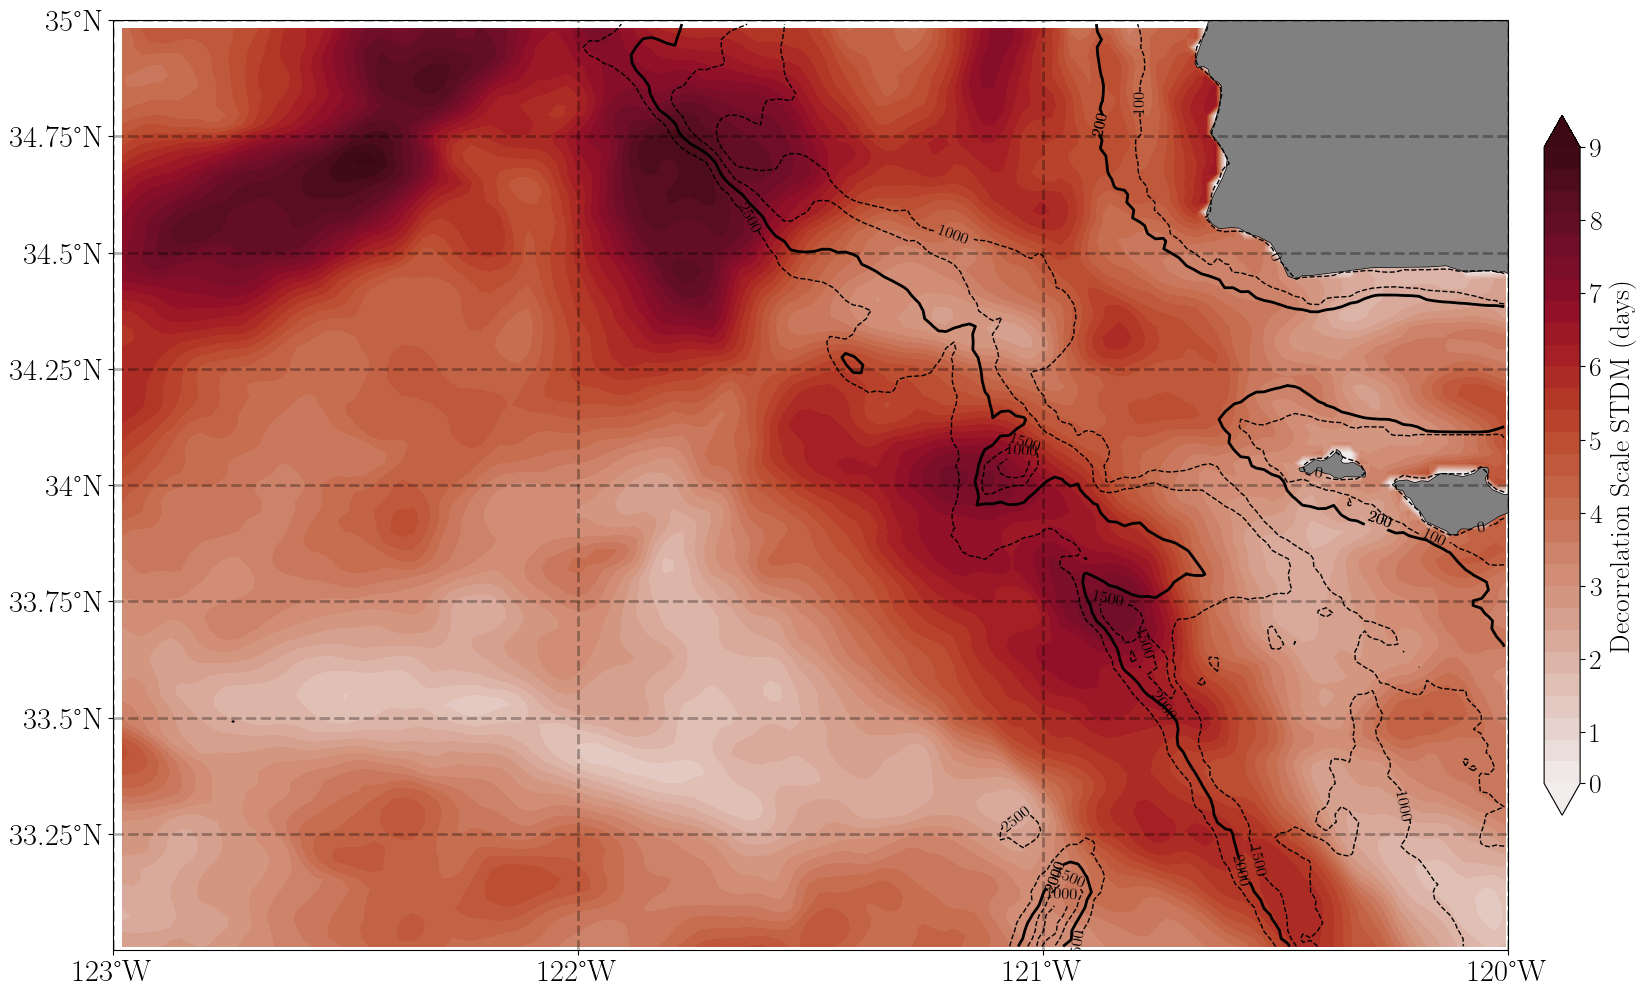

In [9]:
# Set plotting parameters 
levels = np.arange(15,40 + 0.5,0.5) 

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot temporal decorrelation scale
mesh = axes.contourf(
    lon, lat, Lt_stdm_days, levels=30,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.amp,  
    shading="auto", 
    extend = 'both'
)

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=12)
plt.clabel(contour2, fontsize=12)
plt.clabel(contour3, fontsize=12)
plt.clabel(contour4, fontsize=12)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=22,
    color="black",
)

# Create colormap
cax = plt.axes([0.92, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label=r'Decorrelation Scale STDM (days)',
    nbins=10,
    fontsize=20,
    cbar_ticks=[],
    task="regular",
)

# Show the plot
plt.show()

Save intermediate data 

In [ ]:
#--- Autocorrelation and decorrelation scales ---# 

# Check if file exists, then delete it
if option_unc == True: 
    file_path = PATH + "/mitgcm_regional_temporal_scale_" + option_var  + "_depth_" + str(option_depth) + "m_unc.npz"
else: 
    file_path = PATH + "/mitgcm_regional_temporal_scale_" + option_var  + "_depth_" + str(option_depth) + "m.npz"
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Decorrelation time scale from the MIT gcm model out of ' + option_var + ' at depth ' + str(option_depth) + 'm. Here, the annual and semi-annual cycles are removed before computing the decorrelation scale.',
    'source': 'MITgcm model data from SWOT_MARA_RUN4_LY',
    'coordinates units': 'km'
}

# Save data arrays and metadata to a .npz file
if option_unc == 1: 
    np.savez(file_path, 
            Lt_days         = Lt_days,           # Units: days
            Lt_stdm_days    = Lt_stdm_days,      # Units: days
            lon             = lon,
            lat             = lat,
            metadata        = metadata
            )
else: 
    print('Need to save file!!!')